In [1]:
import pandas as pd
import statsmodels.api as sm

<Axes: >

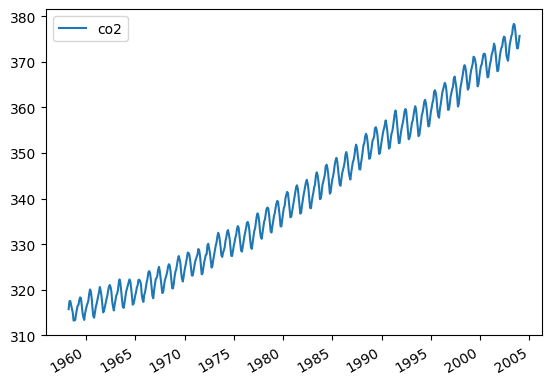

In [2]:
data = pd.read_csv("maunaloa2Co2.csv")
data.index = pd.date_range("1958-01-21", periods=data.shape[0], freq="ME")
data= data[data["co2"] > 0]
data.plot()

On a une tendance linéaire

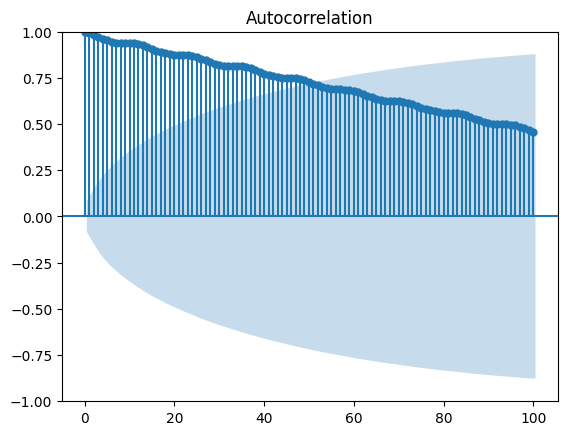

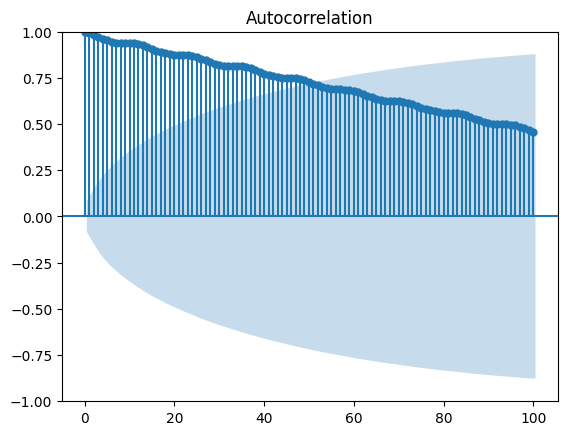

In [3]:
sm.graphics.tsa.plot_acf(data, alpha=0.05,lags=100)

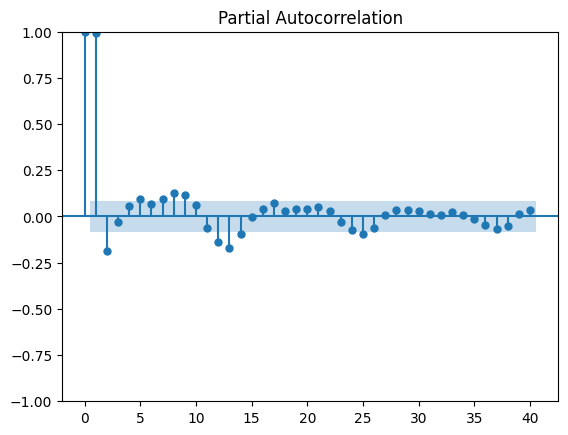

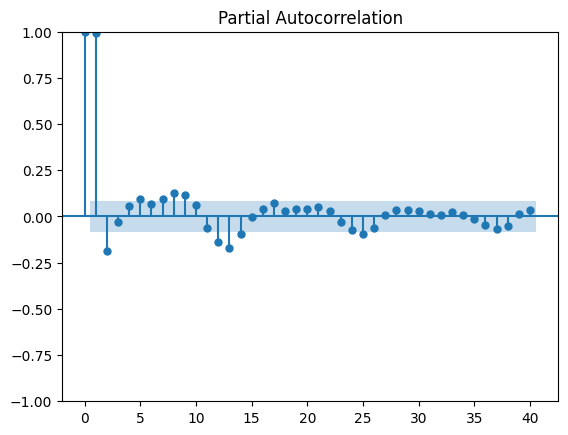

In [4]:
sm.graphics.tsa.plot_pacf(data,alpha=0.05, lags=40)

<Axes: >

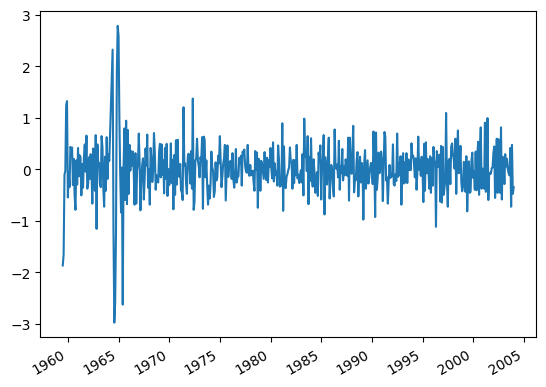

In [5]:
data["diff"] = sm.tsa.statespace.tools.diff(data[abs(data['co2']) > 100], k_diff=1, k_seasonal_diff=1,seasonal_periods=12)
data["diff"].plot()

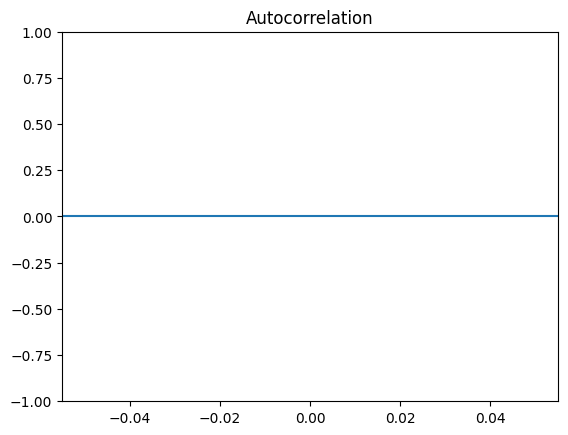

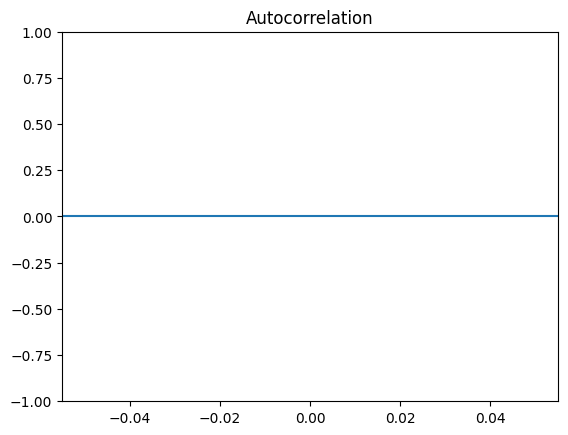

In [6]:
sm.graphics.tsa.plot_acf(data["diff"], alpha=0.05,lags=10)

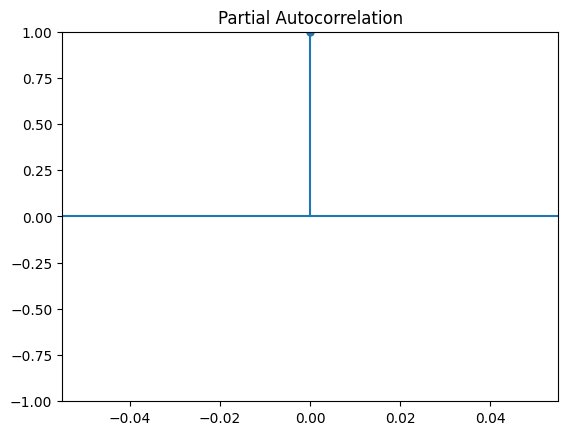

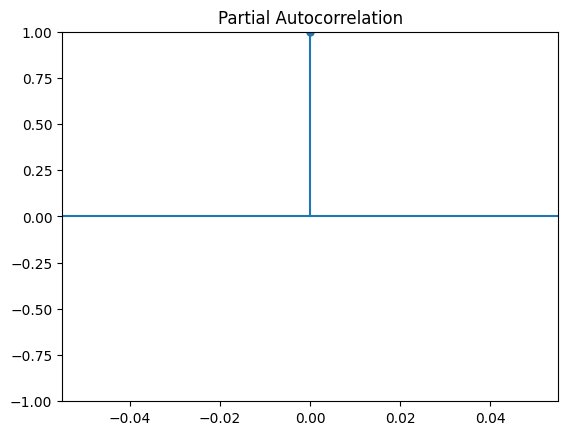

In [7]:
sm.graphics.tsa.plot_pacf(data["diff"], alpha=0.05,lags=100)

<Axes: >

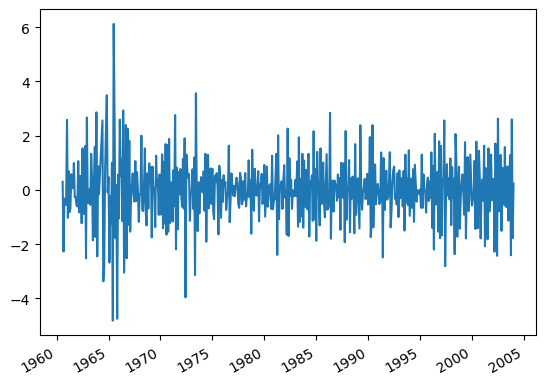

In [8]:
data = pd.read_csv("maunaloa2Co2.csv")
data.index = pd.date_range("1958-01-21", periods=data.shape[0], freq="ME")
data= data[data["co2"] > 0]
data["diff"] = sm.tsa.statespace.tools.diff(data[abs(data['co2']) > 100], k_diff=2, k_seasonal_diff=2,seasonal_periods=12)
data["diff"].plot()

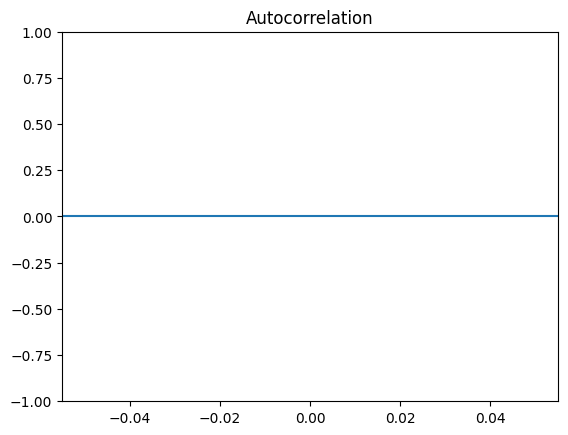

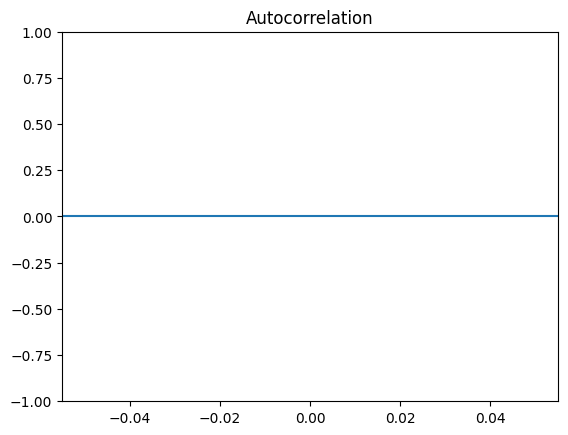

In [9]:
sm.graphics.tsa.plot_acf(data["diff"], alpha=0.05,lags=100)

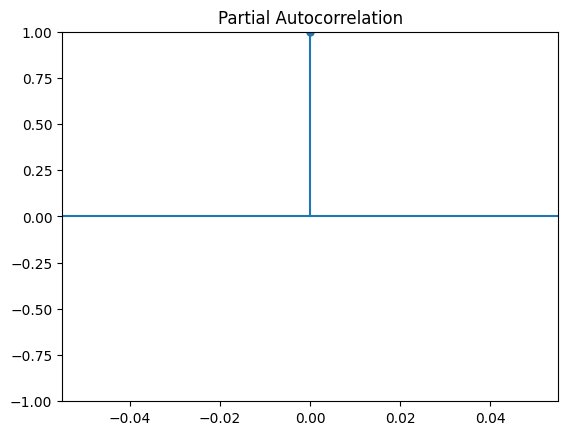

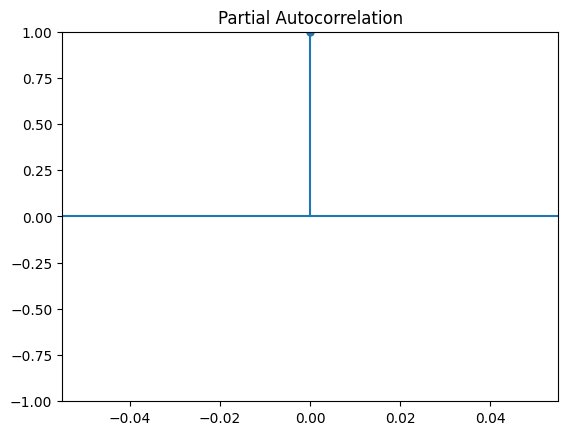

In [10]:
sm.graphics.tsa.plot_pacf(data["diff"], alpha=0.05,lags=100)

In [11]:
model = sm.tsa.ARIMA(data["co2"], order=(1,2,1)).fit()
model.summary()

c:\Data\projets\random-machine-learning\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Data\projets\random-machine-learning\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Data\projets\random-machine-learning\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    co2   No. Observations:                  545
Model:                 ARIMA(1, 2, 1)   Log Likelihood                -719.450
Date:                Sat, 10 Jan 2026   AIC                           1444.901
Time:                        23:22:52   BIC                           1457.792
Sample:                             0   HQIC                          1449.941
                                - 545                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1479      0.185      0.800      0.423      -0.214       0.510
ma.L1          0.1406      0.182      0.772      0.440      -0.217       0.498
sigma2         0.8285      0.046     18.031      0.000       0.738       0.919
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                28.29
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               1.00   Skew:                             0.49
Prob(H) (two-sided):                  0.98   Kurtosis:                         3.54
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<Axes: >

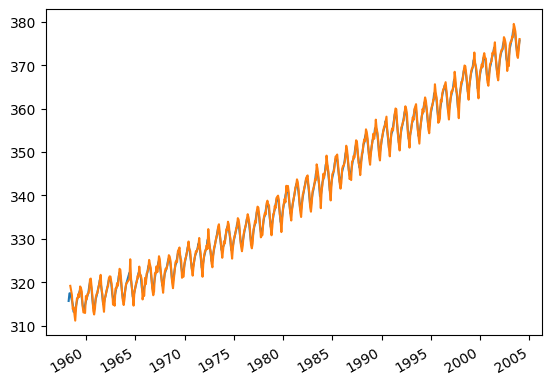

In [12]:
smothed = model.fittedvalues
data["co2"].plot()
smothed["1958-05-31":].plot()